In [4]:
import SimpleITK as sitk
import numpy as np
import os
import matplotlib.pyplot as plt

# resmaple the US image to isotropic spacing of 0.5mm x 0.5mm x 0.5mm

def resample_us_image(us_image_path, new_spacing):
    # read the image
    us_image = sitk.ReadImage(us_image_path)
    print('US Image Size:', us_image.GetSize())
    print('US Image Spacing:', us_image.GetSpacing())
    print('US Image Origin:', us_image.GetOrigin())
    print('US Image Direction:', us_image.GetDirection())

    #I want to resample the image to have isotropic spacing of 0.5mm x 0.5mm x 0.5mm
    new_spacing = [new_spacing[0], new_spacing[1], new_spacing[2]]
    original_size = us_image.GetSize()
    original_spacing = us_image.GetSpacing()
    new_size = [int(round(original_size[i] * (original_spacing[i] / new_spacing[i]))) for i in range(3)]
    resample = sitk.ResampleImageFilter()
    resample.SetOutputSpacing(new_spacing)
    resample.SetSize(new_size)
    resample.SetOutputDirection(us_image.GetDirection())
    resample.SetOutputOrigin(us_image.GetOrigin())

    resample.SetInterpolator(sitk.sitkLinear)
    resampled_image = resample.Execute(us_image)
    print('Resampled Image Size:', resampled_image.GetSize())
    print('Resampled Image Spacing:', resampled_image.GetSpacing())
    print('Resampled Image Origin:', resampled_image.GetOrigin())
    print('Resampled Image Direction:', resampled_image.GetDirection())
    #save the resampled image
    #sitk.WriteImage(resampled_image, output_path)
    return resampled_image

#write image slice to png function
"""skip_indx: int, 
slice_direction: 0, 1, 2 axial, sagittal, coronal, 
output_path: str
"""
def slice_to_png(image, skip_index, output_path):
    """
    每隔 skip_index 张切一张, 分别沿3个方向保存 (axial, sagittal, coronal)
    参数:
        image: SimpleITK.Image 或 .nii/.nii.gz 路径
        skip_index: int, 表示间隔 (e.g., 2 表示 0,2,4,6,...)
        output_path: 保存文件夹路径
    """
    # ---- 1. 如果传的是路径，先读入 SimpleITK 图像 ----
    if isinstance(image, str):
        image = sitk.ReadImage(image)
        print(f"Loaded image from: {image}")

    # ---- 2. 创建三个方向文件夹 ----
    dirs = {
        'axial':    os.path.join(output_path, 'axial'),
        'sagittal': os.path.join(output_path, 'sagittal'),
        'coronal':  os.path.join(output_path, 'coronal')
    }
    for d in dirs.values():
        os.makedirs(d, exist_ok=True)

    size = image.GetSize()  # (x, y, z)
    print(f"Image size (x, y, z): {size}")
    print(f"Skip step = {skip_index}")

    # ---- 3. 定义三个方向的切片与保存逻辑 ----

    # --- Axial (Z 方向) ---
    for i in range(0, size[2], skip_index):
        arr = sitk.GetArrayFromImage(image[:, :, i])
        #arr = normalize_slice(arr)
        #plt.imsave(os.path.join(dirs['axial'], f"slice_{i:03d}.png"), arr, cmap='gray')

    # --- Sagittal (X 方向) ---
    for i in range(0, size[0], skip_index):
        arr = sitk.GetArrayFromImage(image[i, :, :])
        #arr = normalize_slice(arr)
        #plt.imsave(os.path.join(dirs['sagittal'], f"slice_{i:03d}.png"), arr, cmap='gray')

    # --- Coronal (Y 方向) ---
    for i in range(0, size[1], skip_index):
        arr = sitk.GetArrayFromImage(image[:, i, :])
        #arr = normalize_slice(arr)
        #plt.imsave(os.path.join(dirs['coronal'], f"slice_{i:03d}.png"), arr, cmap='gray')

    print(f"✅ Slices saved to: {output_path}")



    
    



In [ ]:
import matplotlib.pyplot as plt
import numpy as np

image_path='G:\\Dino3Registration\\data\\orginal_data\\Case6\\MRI\\Case6-T1.nii.gz'

resample_image_array=resample_us_image(image_path,[0.5,0.5,0.5])
print("resample_image_array size:",resample_image_array.GetSize())
# resamle to [224,192,224]
# resample_us_image_array = resample_us_image_array.astype(np.float32)
# resample_us_image_array = (resample_us_image_array - resample_us_image_array.min()) / (resample_us_image_array.max() - resample_us_image_array.min() + 1e-8)
# resample_us_image_array = (resample_us_image_array * 255).astype(np.uint8)

slice_to_png(resample_image_array,2,"G:\\Dino3Registration\\data\\sliced_png\\Case6\\MRI")






US Image Size: (192, 256, 256)
US Image Spacing: (1.0, 1.0, 1.0)
US Image Origin: (95.12328338623047, 128.9263916015625, -178.67062377929688)
US Image Direction: (-0.9998964952548128, 0.003493001145974097, 0.013956995530026823, -0.0034926593149307242, -0.9999938994528811, 4.887602646610684e-05, 0.013957080928748195, 1.2393891520834897e-07, 0.9999025951996068)
Resampled Image Size: (384, 512, 512)
Resampled Image Spacing: (0.5, 0.5, 0.5)
Resampled Image Origin: (95.12328338623047, 128.9263916015625, -178.67062377929688)
Resampled Image Direction: (-0.9998964952548128, 0.003493001145974097, 0.013956995530026823, -0.0034926593149307242, -0.9999938994528811, 4.887602646610684e-05, 0.013957080928748195, 1.2393891520834897e-07, 0.9999025951996068)
resample_image_array size: (384, 512, 512)
Image size (x, y, z): (384, 512, 512)
Skip step = 2
✅ Slices saved to: G:\Dino3Registration\data\sliced_png\Case6\MRI


File: G:\Dino3Registration\data_pre\US_image_resampled_Bspline.jpeg
Shape (H, W): (369, 231)
Data type: float32
Min intensity: 3.0
Max intensity: 241.0
Mean intensity: 53.744728
Std intensity: 33.69353
Non-zero pixel ratio: 1.0


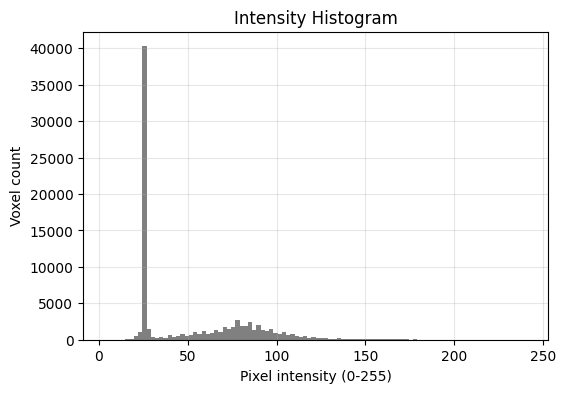

In [59]:
#check png image intensity



import numpy as np
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

# === 修改为你的 PNG 路径 ===
png_path = r"G:\Dino3Registration\data_pre\US_image_resampled_Bspline.jpeg"
#png_path=r"G:\\Dino3Registration\\test_feature\\US_image\\Case1-US-before.jpeg"
# 1) 读取 PNG 图像并确保方向正确
img = Image.open(png_path)
img = ImageOps.exif_transpose(img)   # 修正 EXIF 旋转

# 2) 转为灰度（即单通道）
if img.mode != "L":
    img_gray = img.convert("L")
else:
    img_gray = img

# 3) 转 numpy array
arr = np.array(img_gray).astype(np.float32)

# 4) 打印统计信息
print(f"File: {png_path}")
print("Shape (H, W):", arr.shape)
print("Data type:", arr.dtype)
print("Min intensity:", np.min(arr))
print("Max intensity:", np.max(arr))
print("Mean intensity:", np.mean(arr))
print("Std intensity:", np.std(arr))
print("Non-zero pixel ratio:", np.count_nonzero(arr) / arr.size)

# 5) 绘制强度分布直方图
plt.figure(figsize=(6,4))
plt.hist(arr.flatten(), bins=100, color='gray')
plt.title("Intensity Histogram")
plt.xlabel("Pixel intensity (0-255)")
plt.ylabel("Voxel count")
plt.grid(alpha=0.3)
plt.show()



File: G:\\Dino3Registration\\data_pre\\US_image_resampled.jpeg
Shape (H, W): (369, 231)
Data type: float32
Min intensity: 0.0
Max intensity: 242.0
Mean intensity: 32.353218
Std intensity: 38.669872
Non-zero pixel ratio: 0.513802367460904


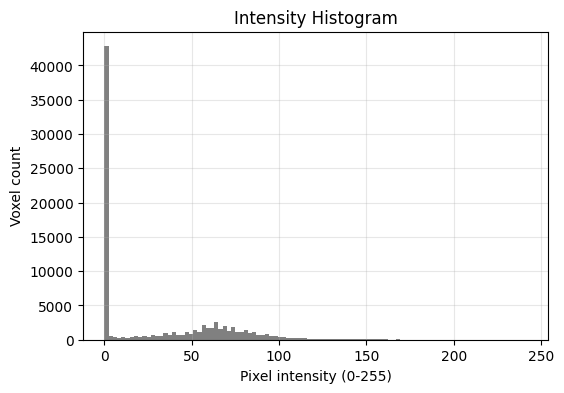

In [58]:
png_path = r"G:\\Dino3Registration\\data_pre\\US_image_resampled.jpeg"
#png_path=r"G:\\Dino3Registration\\test_feature\\US_image\\Case1-US-before.jpeg"
# 1) 读取 PNG 图像并确保方向正确
img = Image.open(png_path)
img = ImageOps.exif_transpose(img)   # 修正 EXIF 旋转

# 2) 转为灰度（即单通道）
if img.mode != "L":
    img_gray = img.convert("L")
else:
    img_gray = img

# 3) 转 numpy array
arr = np.array(img_gray).astype(np.float32)

# 4) 打印统计信息
print(f"File: {png_path}")
print("Shape (H, W):", arr.shape)
print("Data type:", arr.dtype)
print("Min intensity:", np.min(arr))
print("Max intensity:", np.max(arr))
print("Mean intensity:", np.mean(arr))
print("Std intensity:", np.std(arr))
print("Non-zero pixel ratio:", np.count_nonzero(arr) / arr.size)

# 5) 绘制强度分布直方图
plt.figure(figsize=(6,4))
plt.hist(arr.flatten(), bins=100, color='gray')
plt.title("Intensity Histogram")
plt.xlabel("Pixel intensity (0-255)")
plt.ylabel("Voxel count")
plt.grid(alpha=0.3)
plt.show()


In [1]:
from transformers import pipeline
from transformers.image_utils import load_image

url = "G:\\Dino3Registration\\data\\sliced_png\\Case6\\MRI\\coronal\\slice_224.png"
image = load_image(url)
#print image size
print(f"[info] image size: {image.size}")
feature_extractor = pipeline(
    model="facebook/dinov3-vitl16-pretrain-lvd1689m",
    task="image-feature-extraction", 
)
features = feature_extractor(image)
import numpy as np
# Convert features to numpy array and print its shape
features_np = np.array(features)
print(features_np.shape)

#save the features to a npy file
np.save("G:\\Dino3Registration\\test_feature\\encoderTest\\pipelen_encoder_features_case6_mri_slice224.npy", features_np)

c:\Users\Ruoya\anaconda3\envs\dino3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[info] image size: (384, 512)


Fetching 1 files: 100%|██████████| 1/1 [00:00<?, ?it/s]
Device set to use cpu


(1, 201, 1024)


In [ ]:
#wirte a code to patch the image by 16

In [7]:
# fixed the image spacing and only change the image size

MODEL_NAME = "facebook/dinov3-vitl16-pretrain-lvd1689m"   # ViT-L/16 变体


SAVE_PATH  = "G:\\Dino3Registration\\test_feature\\dino3\\"+MODEL_NAME.split("/")[-1]+"_featurecheck.png"
print("SAVE_PATH:",SAVE_PATH)

SAVE_PATH: G:\Dino3Registration\test_feature\dino3\dinov3-vitl16-pretrain-lvd1689m_featurecheck.png


MODEL_NAME = "facebook/dinov3-vitl16-pretrain-lvd1689m"   # ViT-L/16 变体
IMAGE_PATH = r"G:\\Dino3Registration\\data\\sliced_png\\Case6\\MRI\\coronal\\slice_224.png"
# save name add the context after model name /dinov3-

SAVE_PATH  = "G:\\Dino3Registration\\test_feature\\dino3\\"+MODEL_NAME.split("/")[-1]+"_featurecheck.png"
